# L21 · 🎨 矩阵即滤波 — DFT 矩阵 / Mel 矩阵：音频处理 = 矩阵乘法

把《Art of Linear Algebra》的视角对准 Audio Core：
**DFT 是一次矩阵×向量；mel 特征是一次矩阵×向量。** 看懂这点，FFT 和 mel 滤波就从"黑箱公式"变成你已经会的线代。

## 本课剧情：让空间动起来

Audio Core 里的 FFT 和 mel 滤波都可以写成矩阵×向量：`X = W·x`，`m = M·p`。本节把这两个矩阵显式构造出来，用 `mat_times_vec` 图直观地看清：每个输出值是输入向量的一次加权点积。

In [1]:
import numpy as np
from laviz import style, heatmap, mat_times_vec
from aurora.audio import fft, mel_filterbank, sine
style(); print('就绪')

就绪


## 符号入口：先看形状，再看运算

信号向量 `x` 的 shape 是 `(N,)`，DFT 矩阵 `W` 是 `(N, N)`，mel 矩阵 `M` 是 `(n_mels, N//2+1)`。矩阵乘法把输入的每个分量重新线性组合——输出的每个值是一次点积。

## 动手观察：线代对象先看形状，再看意义

运行下面这格，读 `A @ v` 的数值：对角矩阵 `A = diag(2, 0.5)` 把 x 轴拉伸、y 轴压缩，向量长度 `||v||` 随之改变。这是 mel 滤波器对不同频率赋予不同权重的最简化模型。

In [ ]:
import numpy as np

v = np.array([3.0, 4.0])
A = np.array([[2.0, 0.0],
              [0.0, 0.5]])

print('v =', v, 'shape =', v.shape)
print('A =')
print(A)
print('A shape =', A.shape)
print('A @ v =', A @ v)
print('向量长度 ||v|| =', np.linalg.norm(v))


## 代码实验：遍历几个向量，观察矩阵如何改变它们

矩阵 `A = [[2, 1], [0, 1]]` 同时有拉伸和剪切——四个不同方向的探针向量被移动的距离各不相同。

In [ ]:
import numpy as np

A = np.array([[2.0, 1.0],
              [0.0, 1.0]])
vectors = [np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([1.0, 1.0]), np.array([2.0, -1.0])]

print('A =')
print(A)
for v in vectors:
    out = A @ v
    print(f'v={v} -> A@v={out}')


## 1. DFT 是一个矩阵 W

离散傅里叶变换 `X = W·x`，其中 `W[k,n] = e^{-2πi·kn/N}`。它是一个 N×N 的**复数矩阵**——下面画出它的实部与虚部。

把音频管道写成矩阵链乘有两个实际好处：第一，每一步都有明确的 shape——`W` 是 `(N, N)`、mel 矩阵 `M` 是 `(n_mels, N//2+1)`——任何维度错误立即被矩阵乘法的形状规则暴露；第二，FFT 和 mel 滤波背后的线性结构变得透明，批量处理只需把输入从向量扩展为矩阵（多帧信号），整个管道自然向量化，无需逐帧循环。

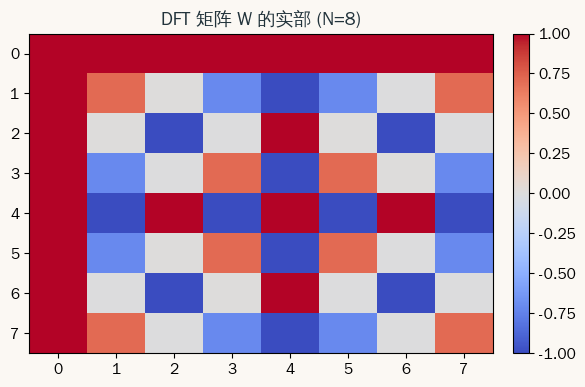

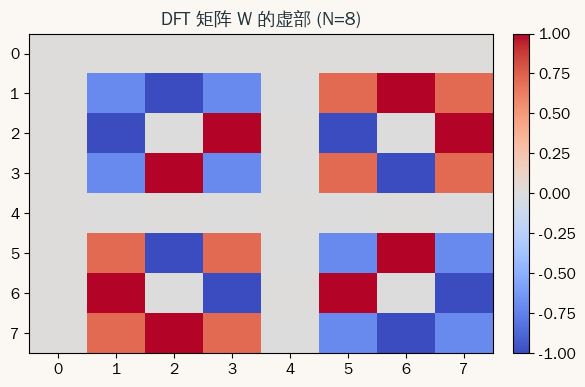

In [2]:
N = 8
k = np.arange(N)[:, None]; n = np.arange(N)[None, :]
W = np.exp(-2j*np.pi*k*n/N)        # DFT 矩阵
heatmap(W.real, title='DFT 矩阵 W 的实部 (N=8)', cmap='coolwarm');
heatmap(W.imag, title='DFT 矩阵 W 的虚部 (N=8)', cmap='coolwarm');

## 2. 验证：`W·x` 和我们手写的 FFT 完全一致

`W @ x` 与 `src/aurora/audio/transforms.py` 中的 `fft()` 算的是同一变换：前者是 O(N²) 的显式矩阵乘，后者是 O(N log N) 的蝶形递归，两者数值结果相差不超过浮点误差（`atol=1e-10`）。`mel_filterbank()` 在 `src/aurora/audio/mel.py` 中同理——显式构造矩阵 `M` 后，`M @ p` 与 `mel_filterbank()` 对功率谱 `p` 的输出完全一致。

In [3]:
x = sine(1.0, duration=N/8, sample_rate=8)[:N]   # 任取一段长度为 N 的信号
X_matrix = W @ x          # 矩阵 × 向量
X_fft = fft(x)            # 我们手写的 FFT
print('W·x 与 fft(x) 一致:', np.allclose(X_matrix, X_fft))
assert np.allclose(X_matrix, X_fft)
print('✅ FFT 的本质 = 一次矩阵×向量(只是算得更快)。')

W·x 与 fft(x) 一致: True
✅ FFT 的本质 = 一次矩阵×向量(只是算得更快)。


## 3. mel 滤波器组也是一个矩阵

mel 特征 = `M · p`，其中 `M` 是 (n_mels × n_freq) 的滤波器矩阵，`p` 是功率谱向量。画出 M——一排漂亮的三角滤波器。

mel 滤波器矩阵形状: (10, 33) = (n_mels, n_freq_bins)


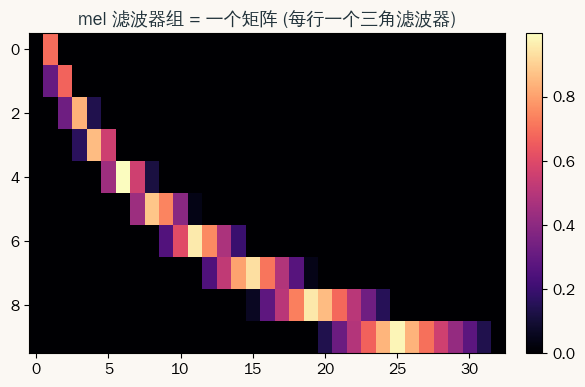

In [4]:
M = mel_filterbank(n_mels=10, n_fft=64, sample_rate=16000)
print('mel 滤波器矩阵形状:', M.shape, '= (n_mels, n_freq_bins)')
heatmap(M, title='mel 滤波器组 = 一个矩阵 (每行一个三角滤波器)', cmap='magma');

## 4. "每个 mel 值 = 频率bins 的一次加权点积" (Mv1 视角)

取一个小例子：把功率谱 `p` 乘以滤波器矩阵的前几行，用 `mat_times_vec` 画成"矩阵×向量"。

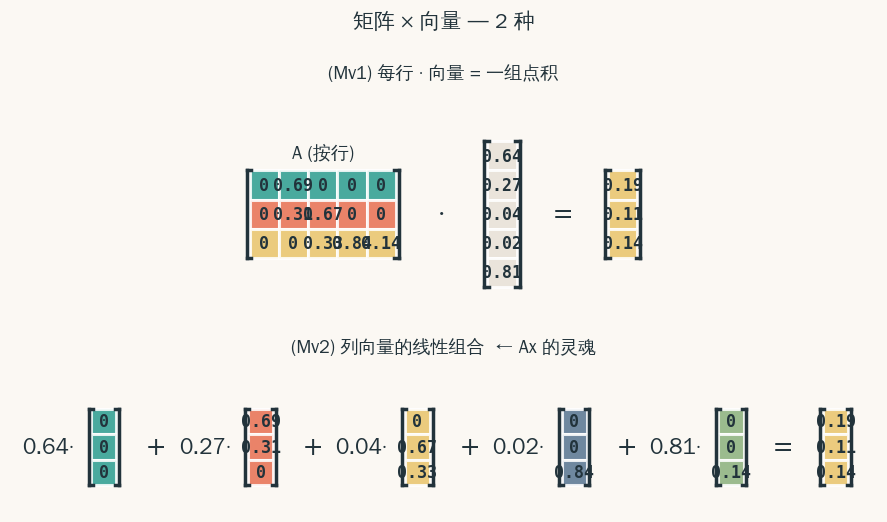

In [5]:
rng = np.random.default_rng(0)
Msmall = np.round(M[:3, :5], 2)         # 取 3 个滤波器 × 5 个频点
p = np.round(rng.random(5), 2)          # 假装的功率谱
mat_times_vec(Msmall, p);               # 每个 mel = 一行·p = 点积

**🎉 收束**：
- **FFT** = 矩阵 `W` × 信号（`v1` 的 Mv 图）
- **mel 特征** = 矩阵 `M` × 功率谱
- **神经网络层** = 矩阵 `W` × 输入

同一张「矩阵×向量」的图，贯穿 Audio Core 到深度学习。这就是用**图形化思维**把线代和 Aurora 焊在一起。

In [ ]:
A = np.array([[2.0, 1.0], [0.0, 1.0]])
probes = np.array([[1,0], [0,1], [1,1], [-1,2]], dtype=float)
print('矩阵 A 会怎样移动这些向量？')
for v in probes:
    out = A @ v
    print(f'{v} -> {out} | 长度 {np.linalg.norm(v):.2f} -> {np.linalg.norm(out):.2f}')


## 参数实验：只改一个旋钮

把 `mel_filterbank` 的 `n_mels` 从 `80` 改到 `40`：mel 矩阵 `M` 的 shape 从 `(80, F)` 变为 `(40, F)`，最终特征向量维度减半。减少滤波器数量会使相邻频率 bin 被合并进同一个三角窗，高频细节分辨率下降。反向将 `n_mels` 增到 `128`，观察矩阵行数增加后滤波器重叠程度如何变化，以及 `M @ p` 输出向量的长度是否随之同步增长。

In [ ]:
A = np.array([[2.0, 1.0], [0.0, 1.0]])
probes = np.array([[1,0], [0,1], [1,1], [-1,2]], dtype=float)
print('矩阵 A 会怎样移动这些向量？')
for v in probes:
    out = A @ v
    print(f'{v} -> {out} | 长度 {np.linalg.norm(v):.2f} -> {np.linalg.norm(out):.2f}')


## 本课收束

现在可以显式构造 DFT 矩阵 `W = exp(-2πi·kn/N)`，运行 `W @ x` 并与 `fft(x)` 数值对比，两者完全一致。mel 矩阵 `M` 的每一行是一个三角滤波器，`M @ p` 等于 `mel_filterbank()` 对功率谱向量 `p` 的输出。这两个变换在 Audio Core 里分别封装为 `fft()` 和 `mel_filterbank()`，底层都是加权点积。下一节进入特征分解，矩阵×向量的框架还会继续用于分析变换的主方向。

In [ ]:
# 小检查：先看 shape，再做运算
import numpy as np

a = np.array([1.0, 2.0])
b = np.array([3.0, 4.0])
A = np.array([[1.0, 2.0], [0.0, 1.0]])

print('a.shape =', a.shape)
print('b.shape =', b.shape)
print('A.shape =', A.shape)
print('a + b =', a + b)
print('A @ a =', A @ a)
print('a dot b =', float(a @ b))
